In [1]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

# Standard library imports
import argparse
import importlib.util
import inspect
import json
import math
import os
import pickle
import random
import shutil
import socket
import subprocess
import sys
import tempfile
import warnings
from functools import reduce

# Third-party imports
import librosa
import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger
from matplotlib import cm
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from tqdm import tqdm

from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget, BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Local imports
import commons
import lightning_wrapper
import losses
import models
import utils
import train
from cough_datasets import (
    CoughDatasets,
    CoughDatasetsCollate,
    CoughDatasetsProcessorCollate,
    CoughDetectionRatioBatchSampler,
    CoughDiseaseBinaryBatchSampler,
    PatientBatchSampler
)

torch.set_float32_matmul_precision("medium")
cmap = cm.get_cmap("viridis")

class CAMWrapper(torch.nn.Module):
    def __init__(self, lightning_model):
        super().__init__()
        self.lightning_model = lightning_model

    def forward(self, x):
        out = self.lightning_model(x)
        return out["disease_logits"]

class SplitStreamCAMWrapper(nn.Module):
    def __init__(self, model, stream_idx: int):
        super().__init__()
        self.model = model
        self.stream_idx = stream_idx  # 0=raw, 1=delta, 2=deltadelta

    def forward(self, s):
        z = self.model.forward_encoder(s.unsqueeze(1))
        logits = self.model.classifier(z)
        return logits

def minmax_norm(x, eps=1e-8):
    return (x - x.min()) / (x.max() - x.min() + eps)

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


/tmp/ipykernel_1757612/704145914.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


In [2]:
log_folder = "./logs_nfft2048"
experiments = ["bilstmatt_logmel"] # , "bilstmatt_mfcc"
use_cpu = False

dfs = []
for now_experiment in experiments:
    parser = train.parse_args()
    args = parser.parse_args(["--model_name", now_experiment])
    model_dir = os.path.join(log_folder, args.model_name)

    config_path = args.config_path if args.init else os.path.join(model_dir, "config.json")
    hps = train.load_config(config_path, model_dir, args)

    # =============================================================
    # SECTION: Loading Data
    # =============================================================
    df_train, df_test = train.load_data(hps)
    collate_fn = train.get_collate_fn(hps)
    target_labels = df_train[hps.data.target_column]

    logger = utils.get_logger(hps.model_dir, filename="dummy.log")
    logger.info(hps)

    pool_net, pool_model = train.setup_model(hps, is_init=args.init)
    runner_lightning = lightning_wrapper.CoughClassificationRunner.load_from_checkpoint(
        os.path.join(hps.model_dir, "best_model.ckpt"),
        model=pool_model,
        hps=hps, custom_logger=logger
    )
    runner_lightning.eval()
    trainer = L.Trainer(accelerator="gpu" if use_cpu == False else "cpu", devices="auto")

    info_fold_data = train.load_fold_info(hps.model_dir)
    best_fold_idx = info_fold_data.get("best_fold_idx", 0)

    break

    train_dataset = CoughDatasets(
        df_train.values, 
        hps.data,
        wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{best_fold_idx}.pickle", 
        train=False
    )
    test_dataset = CoughDatasets(
        df_test.values, 
        hps.data,
        wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{best_fold_idx}.pickle", 
        train=False
    )
    
    # Create sampler
    #sampler = train.create_sampler(train_fold, hps)
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset, 
        num_workers=28, 
        #sampler=sampler, 
        batch_size=hps.train.batch_size,
        pin_memory=True, 
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_dataset, 
        num_workers=28, 
        shuffle=False, 
        batch_size=hps.train.batch_size,
        pin_memory=True, 
        collate_fn=collate_fn
    )

    test_wavnames = []
    test_preds = []
    with torch.no_grad():
        for idx, batch in tqdm(enumerate(train_loader), total=len(train_loader)):
            wavnames, audio, _, attention_masks, dse_ids, [patient_ids, _, _] = batch
            audio = audio.cuda()
            attention_masks = attention_masks.cuda()
            out_model = runner_lightning.model.forward(audio, attention_mask=attention_masks)
            logits = out_model['disease_logits']

            probs = torch.sigmoid(logits).squeeze(-1)  # [B]
            #preds = (probs >= 0.5).long()

            test_wavnames.extend(wavnames)
            test_preds.append(probs.cpu())

        for idx, batch in tqdm(enumerate(test_loader), total=len(test_loader)):
            wavnames, audio, _, attention_masks, dse_ids, [patient_ids, _, _] = batch
            audio = audio.cuda()
            attention_masks = attention_masks.cuda()
            out_model = runner_lightning.model.forward(audio, attention_mask=attention_masks)
            logits = out_model['disease_logits']

            probs = torch.sigmoid(logits).squeeze(-1)  # [B]
            #preds = (probs >= 0.5).long()

            test_wavnames.extend(wavnames)
            test_preds.append(probs.cpu())

    del audio, attention_masks
    test_wavnames = np.array(test_wavnames)
    test_preds = torch.cat(test_preds, dim=0).numpy()

    df_now = pd.DataFrame({
        "path_file": test_wavnames,
        now_experiment: test_preds
    })
    dfs.append(df_now)

# final_df = reduce(
#     lambda left, right: pd.merge(left, right, on="path_file", how="inner"),
#     dfs
# )

# df_train['split'] = "train"
# df_test['split'] = "test"

# df_all = pd.concat([df_train, df_test])
# df_all.reset_index(inplace=True, drop=True)

# df_result = df_all.merge(
#     final_df,
#     on="path_file",
#     how="inner",
#     validate="one_to_one"
# )

# test_df_thr = df_result[df_result["split"] == "test"].copy()
# test_df_thr["pred"] = (test_df_thr["bilstmatt_logmel"] >= 0.5).astype(int)

# TP = ((test_df_thr.disease_status == 1) & (test_df_thr.pred == 1)).sum()
# TN = ((test_df_thr.disease_status == 0) & (test_df_thr.pred == 0)).sum()
# FP = ((test_df_thr.disease_status == 0) & (test_df_thr.pred == 1)).sum()
# FN = ((test_df_thr.disease_status == 1) & (test_df_thr.pred == 0)).sum()

# sensitivity = TP / (TP + FN + 1e-9)
# specificity = TN / (TN + FP + 1e-9)

INFO:bilstmatt_logmel:{'train': {'use_cuda': True, 'log_interval': 20, 'seed': 1234, 'epochs': 10000, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'betas': [0.8, 0.99], 'eps': 1e-09, 'lr_decay': 0.999875, 'batch_size': 128, 'loss_function': 'BCE', 'use_Kfold': True, 'mae_training': False, 'ssccl_training': False}, 'data': {'max_wav_value': False, 'mean_std_norm': True, 'per_band_norm': False, 'sampling_rate': 16000, 'filter_length': 2048, 'hop_length': 256, 'win_length': 512, 'n_mel_channels': 80, 'mel_fmin': 50.0, 'mel_fmax': 8000.0, 'saming_length': True, 'desired_length': 0.55, 'fade_samples_ratio': 16, 'pad_types': 'zero', 'rezize_size': [64, 256], 'tabular_feature': True, 'acoustic_feature': True, 'feature_type': 'logmel', 'delta_feature': False, 'deltadelta_feature': False, 'multimask_augment': False, 'tau': 0.1, 'nu': 0.1, 'num_masks': 5, 'augment_data': True, 'augment_prob': 0.5, 'augment_rawboost': True, 'add_noise': False, 'cough_detection': False, 'mix_audio': False, 'ma

INFO:bilstmatt_logmel:Trainable params: 13459073 | Total params: 13459073 | Trainable%: 100.00% | Size: 13.46M


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [3]:
splitter, num_folds = train.create_data_split(df_train, target_labels, use_kfold=hps.train.use_Kfold)
train_idx, val_idx = list(splitter)[best_fold_idx]

In [4]:
train_fold = df_train.iloc[train_idx].reset_index(drop=True)
val_fold = df_train.iloc[val_idx].reset_index(drop=True)
train_loader, val_loader = train.prepare_fold_data(train_fold, val_fold, hps, best_fold_idx, collate_fn)

In [5]:
runner_lightning.probs_threshold

0.5

In [6]:
results = trainer.test(runner_lightning, dataloaders=val_loader)[0]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7111183404922485     │
│        test_auroc         │    0.7689036130905151     │
│         test_bacc         │    0.6935624480247498     │
│        test_pauroc        │            0.0            │
│         test_sens         │    0.5947660803794861     │
│         test_spec         │    0.7923588156700134     │
└───────────────────────────┴───────────────────────────┘

In [7]:
runner_lightning.calibrate_threshold = True
results = trainer.test(runner_lightning, dataloaders=val_loader)[0]
runner_lightning.calibrate_threshold = False
runner_lightning.probs_threshold

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7124225497245789     │
│        test_auroc         │    0.7689036130905151     │
│         test_bacc         │    0.7066354155540466     │
│        test_pauroc        │            0.0            │
│         test_sens         │    0.6740682125091553     │
│         test_spec         │    0.7392026782035828     │
└───────────────────────────┴───────────────────────────┘

0.4484136

In [11]:
if os.path.exists(os.path.join(model_dir, "probs_threshold.pkl")):
    with open(os.path.join(model_dir, "probs_threshold.pkl"), "rb") as f:
        runner_lightning.probs_threshold = pickle.load(f)['probs_threshold']

In [12]:
runner_lightning.probs_threshold

0.4484136

In [10]:
payload = {
    "probs_threshold": runner_lightning.probs_threshold,
}

with open(os.path.join(model_dir, "probs_threshold.pkl"), "wb") as f:
    pickle.dump(payload, f)


In [ ]:
runner_lightning.probs_threshold

In [8]:
df_test_eval = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.test')
df_test_eval = df_test_eval.reset_index(drop=True)
df_test_eval = df_test_eval[hps.data.column_order]
#df_test_eval.drop(columns=["db"], inplace=True)

results_dict = train.evaluate_on_dataset(runner_lightning, trainer, df_test_eval, hps, best_fold_idx, collate_fn, db_column='db')

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.6791626214981079     │
│        test_auroc         │    0.7231988310813904     │
│         test_bacc         │     0.668387770652771     │
│        test_pauroc        │            0.0            │
│         test_sens         │    0.6251621246337891     │
│         test_spec         │    0.7116134166717529     │
└───────────────────────────┴───────────────────────────┘

In [37]:
results_dict

{0: {'test_acc': 0.6616102457046509,
  'test_bacc': 0.5617413520812988,
  'test_sens': 0.32199999690055847,
  'test_spec': 0.8014826774597168,
  'test_auroc': 0.5919983386993408,
  'test_pauroc': 0.0},
 1: {'test_acc': 0.7147147059440613,
  'test_bacc': 0.6116804480552673,
  'test_sens': 0.35902637243270874,
  'test_spec': 0.8643344640731812,
  'test_auroc': 0.6852107048034668,
  'test_pauroc': 0.0},
 3: {'test_acc': 0.8040000200271606,
  'test_bacc': 0.47857141494750977,
  'test_sens': 0.9571428298950195,
  'test_spec': 0.0,
  'test_auroc': 0.4613095223903656,
  'test_pauroc': 0.0},
 2: {'test_acc': 0.7014613747596741,
  'test_bacc': 0.5333122611045837,
  'test_sens': 0.9380530714988708,
  'test_spec': 0.12857143580913544,
  'test_auroc': 0.6973029971122742,
  'test_pauroc': 0.0}}

In [56]:
np.mean([v['test_sens'] for v in results_dict.values()])

0.6440555676817894

In [57]:
np.mean([v['test_spec'] for v in results_dict.values()])

0.44859714433550835

In [30]:
df_result

,path_file,disease_status,gender,participant,weight_loss,hemoptysis,night_sweats,smoker,db,split,bilstmatt_logmel,bilstmatt_mfcc
0,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...,0,0.0,0,1.0,0.0,0.0,0.0,0,train,0.333497,0.522486
1,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...,0,0.0,0,1.0,0.0,0.0,0.0,0,train,0.447046,0.523988
2,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...,0,0.0,0,1.0,0.0,0.0,0.0,0,train,0.460971,0.498806
3,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...,0,0.0,0,1.0,0.0,0.0,0.0,0,train,0.431495,0.394048
4,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...,0,0.0,0,1.0,0.0,0.0,0.0,0,train,0.341399,0.410493
...,...,...,...,...,...,...,...,...,...,...,...,...
19822,/run/media/fourier/Data1/Pras/DatabaseLLM/TBsc...,0,1.0,1089,1.0,0.0,0.0,0.0,2,test,0.634745,0.707630
19823,/run/media/fourier/Data1/Pras/DatabaseLLM/TBsc...,0,1.0,1089,1.0,0.0,0.0,0.0,2,test,0.690122,0.683353
19824,/run/media/fourier/Data1/Pras/DatabaseLLM/TBsc...,0,1.0,1089,1.0,0.0,0.0,0.0,2,test,0.369966,0.591055
19825,/run/media/fourier/Data1/Pras/DatabaseLLM/TBsc...,0,1.0,1089,1.0,0.0,0.0,0.0,2,test,0.420653,0.672935


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve

def optimize_threshold_youden(y_true, y_prob):
    """
    Returns optimal threshold maximizing Sens + Spec (Youden's J).
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)

    return thresholds[best_idx]

In [8]:
train_df_thr = df_result[df_result["split"] == "train"]

opt = optimize_threshold_youden(
    y_true=train_df_thr["disease_status"].values,
    y_prob=train_df_thr["bilstmatt_logmel"].values
)

best_threshold = opt["threshold"]
best_threshold

0.410995

In [42]:
test_df_thr = df_result[df_result["split"] == "test"].copy()

array([0, 0, 0, ..., 0, 0, 1])

In [46]:
preds = (test_df_thr["bilstmatt_logmel"] >= 0.5).astype(int).values
labels = test_df_thr["disease_status"].values
logits = test_df_thr["bilstmatt_logmel"].values

In [47]:
cm = confusion_matrix(labels, preds, labels=[0, 1])
n_classes = cm.shape[0]

# sanity check: binary only
assert cm.shape == (2, 2), f"Expected binary confusion matrix, got {cm.shape}"

TN, FP = cm[0, 0], cm[0, 1]
FN, TP = cm[1, 0], cm[1, 1]

acc = accuracy_score(labels, preds)

# clinical metrics
sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0   # TB recall
spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0   # non-TB recall

In [48]:
sens

0.5557717250324254

In [49]:
spec

0.7809820732657833

In [ ]:
test_df_thr = df_result[df_result["split"] == "test"].copy()
test_df_thr["pred"] = (test_df_thr["bilstmatt_logmel"] >= 0.5).astype(int)

TP = ((test_df_thr.disease_status == 1) & (test_df_thr.pred == 1)).sum()
TN = ((test_df_thr.disease_status == 0) & (test_df_thr.pred == 0)).sum()
FP = ((test_df_thr.disease_status == 0) & (test_df_thr.pred == 1)).sum()
FN = ((test_df_thr.disease_status == 1) & (test_df_thr.pred == 0)).sum()

sensitivity = TP / (TP + FN + 1e-9)
specificity = TN / (TN + FP + 1e-9)

In [28]:
sensitivity

0.555771725032065

In [29]:
specificity

0.780982073265479

# Lets Find Out Why it Fail

In [4]:
# Select Where bilstmatt_logmel always wrong and bilstmatt_mfcc always right
df_filtered = df_result[
    (df_result["split"] == "test") &
    (
        (df_result["bilstmatt_mfcc"] >= 0.5).astype(int)
        == df_result["disease_status"]
    ) &
    (
        (df_result["bilstmatt_logmel"] >= 0.5).astype(int)
        != df_result["disease_status"]
    )
]

In [44]:
out_models = {}
for now_experiment in experiments:
    parser = train.parse_args()
    args = parser.parse_args(["--model_name", now_experiment])
    model_dir = os.path.join(log_folder, args.model_name)

    config_path = args.config_path if args.init else os.path.join(model_dir, "config.json")
    hps = train.load_config(config_path, model_dir, args)
    collate_fn = train.get_collate_fn(hps)

    logger = utils.get_logger(hps.model_dir, filename="dummy.log")
    logger.info(hps)

    pool_net, pool_model = train.setup_model(hps, is_init=args.init)
    runner_lightning = lightning_wrapper.CoughClassificationRunner.load_from_checkpoint(
        os.path.join(hps.model_dir, "best_model.ckpt"),
        model=pool_model,
        hps=hps, custom_logger=logger
    )
    runner_lightning.eval()
    info_fold_data = train.load_fold_info(hps.model_dir)
    best_fold_idx = info_fold_data.get("best_fold_idx", 0)

    test_dataset = CoughDatasets(
        df_filtered.values,
        hps.data,
        wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{best_fold_idx}.pickle",
        train=False
    )

    test_loader = DataLoader(
        test_dataset,
        num_workers=28,
        shuffle=False,
        batch_size=hps.train.batch_size,
        pin_memory=True,
        collate_fn=collate_fn
    )

    with torch.no_grad():
        for idx, batch in tqdm(enumerate(test_loader), total=len(test_loader)):
            wavnames, audio, _, attention_masks, dse_ids, [patient_ids, _, _] = batch
            audio = audio.cuda()
            attention_masks = attention_masks.cuda()
            out_model = runner_lightning.model.forward(audio, attention_mask=attention_masks)
            logits = out_model['disease_logits']

            probs = torch.sigmoid(logits).squeeze(-1)  # [B]
            #preds = (probs >= 0.5).long()
            dse_ids = torch.argmax(dse_ids, dim=1)
            break

        out_models[now_experiment] = {
            'audios': audio.cpu().detach(),
            'dse_ids': dse_ids.cpu().detach(),
            'out_model': out_model,
        }

INFO:bilstmatt_logmel:{'train': {'use_cuda': True, 'log_interval': 20, 'seed': 1234, 'epochs': 10000, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'betas': [0.8, 0.99], 'eps': 1e-09, 'lr_decay': 0.999875, 'batch_size': 128, 'loss_function': 'BCE', 'use_Kfold': True, 'mae_training': False, 'ssccl_training': False}, 'data': {'max_wav_value': False, 'mean_std_norm': True, 'per_band_norm': False, 'sampling_rate': 16000, 'filter_length': 2048, 'hop_length': 256, 'win_length': 512, 'n_mel_channels': 80, 'mel_fmin': 50.0, 'mel_fmax': 8000.0, 'saming_length': True, 'desired_length': 0.55, 'fade_samples_ratio': 16, 'pad_types': 'zero', 'rezize_size': [64, 256], 'tabular_feature': True, 'acoustic_feature': True, 'feature_type': 'logmel', 'delta_feature': False, 'deltadelta_feature': False, 'multimask_augment': False, 'tau': 0.1, 'nu': 0.1, 'num_masks': 5, 'augment_data': True, 'augment_prob': 0.5, 'augment_rawboost': True, 'add_noise': False, 'cough_detection': False, 'mix_audio': False, 'ma

  0%|          | 0/3 [00:00<?, ?it/s]

INFO:bilstmatt_mfcc:{'train': {'use_cuda': True, 'log_interval': 20, 'seed': 1234, 'epochs': 10000, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'betas': [0.8, 0.99], 'eps': 1e-09, 'lr_decay': 0.999875, 'batch_size': 128, 'loss_function': 'BCE', 'use_Kfold': True, 'mae_training': False, 'ssccl_training': False}, 'data': {'max_wav_value': False, 'mean_std_norm': True, 'per_band_norm': False, 'sampling_rate': 16000, 'filter_length': 2048, 'hop_length': 256, 'win_length': 512, 'n_mel_channels': 80, 'mel_fmin': 50.0, 'mel_fmax': 8000.0, 'saming_length': True, 'desired_length': 0.55, 'fade_samples_ratio': 16, 'pad_types': 'zero', 'rezize_size': [64, 256], 'tabular_feature': True, 'acoustic_feature': True, 'feature_type': 'mfcc', 'delta_feature': False, 'deltadelta_feature': False, 'multimask_augment': False, 'tau': 0.1, 'nu': 0.1, 'num_masks': 5, 'augment_data': True, 'augment_prob': 0.5, 'augment_rawboost': True, 'add_noise': False, 'cough_detection': False, 'mix_audio': False, 'many_c


  0%|          | 0/3 [00:00<?, ?it/s]


/tmp/ipykernel_1229390/1220370724.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


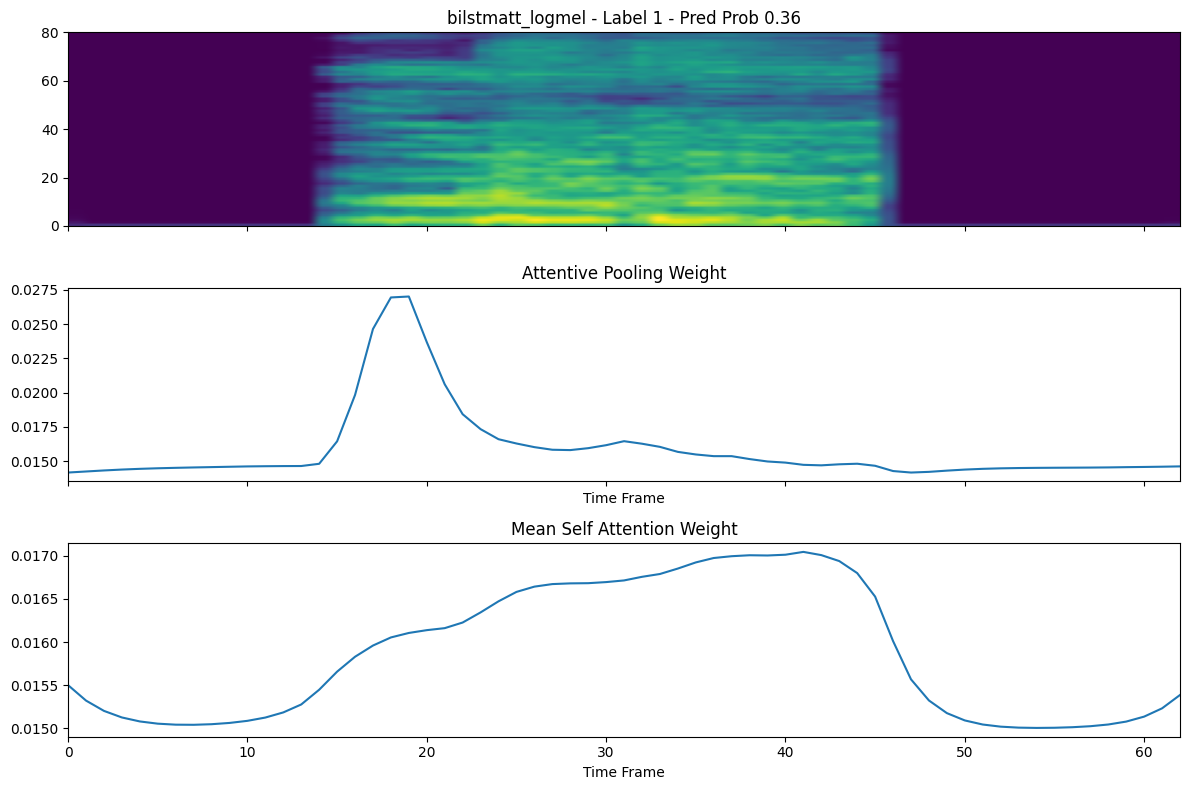

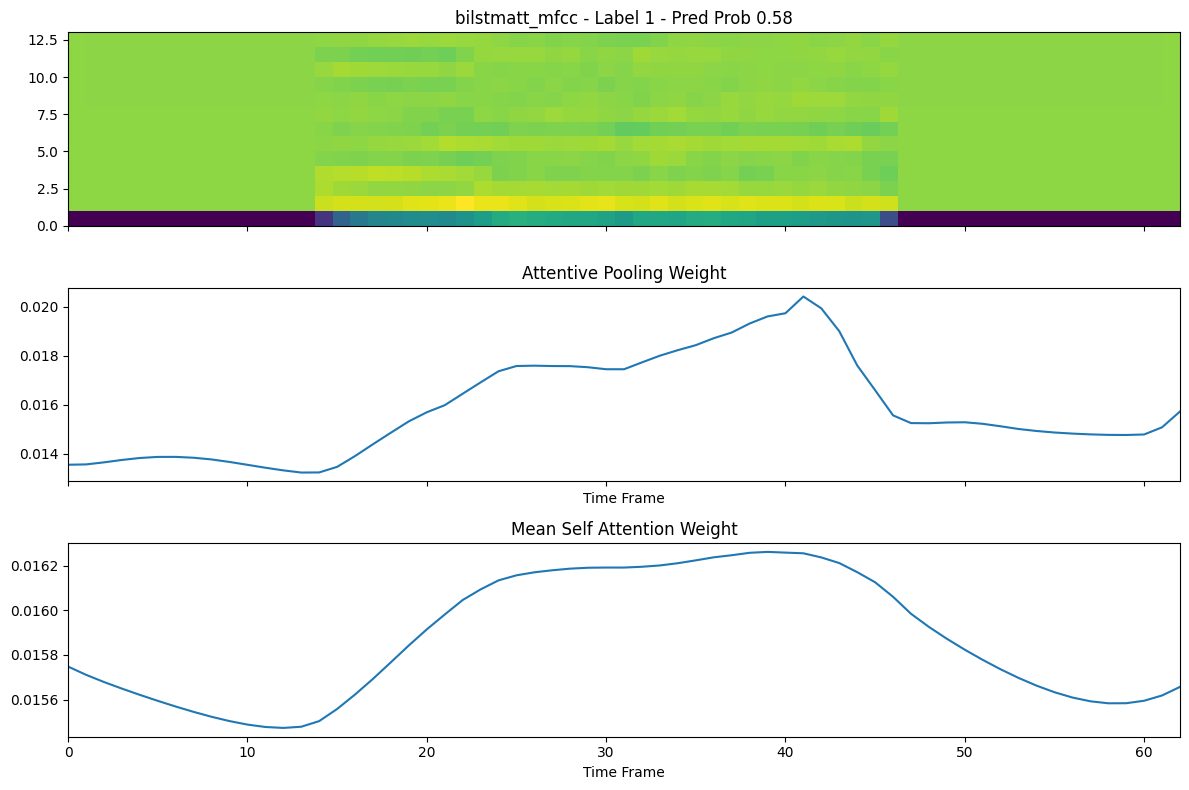

In [73]:
selected_index = random.randint(0, len(out_models['bilstmatt_logmel']['audios']) - 1)

selected_experiment = "bilstmatt_logmel"
for selected_experiment in out_models.keys():
    probs = torch.sigmoid(out_models[selected_experiment]['out_model']['disease_logits']).squeeze(-1)
    feature_model1 = minmax_norm(out_models[selected_experiment]['audios'][selected_index])
    t_att = out_models[selected_experiment]['out_model']['asp_weights'][selected_index].mean(dim=0).cpu().detach().numpy()
    se_att = out_models[selected_experiment]['out_model']['self_attn_weights'][selected_index].mean(dim=0).cpu().detach().numpy()
    time_x = np.arange(feature_model1.shape[-1])

    mel_np = np.flipud(feature_model1.numpy())
    cmap = cm.get_cmap("viridis")
    mel_rgb = cmap(mel_np)[..., :3]

    preds_prob = probs[selected_index]
    true_label = out_models[selected_experiment]['dse_ids'][selected_index]

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)
    axes[0].imshow(mel_rgb, aspect='auto', extent=[time_x[0], time_x[-1], 0, mel_rgb.shape[0]])
    axes[0].set_title(f"{selected_experiment} - Label {true_label} - Pred Prob {preds_prob:.2f}")

    axes[1].plot(time_x, t_att)
    axes[1].set_title("Attentive Pooling Weight")
    axes[1].set_xlabel("Time Frame")

    axes[2].plot(time_x, se_att)
    axes[2].set_title("Mean Self Attention Weight")
    axes[2].set_xlabel("Time Frame")

    plt.tight_layout()
    plt.show()

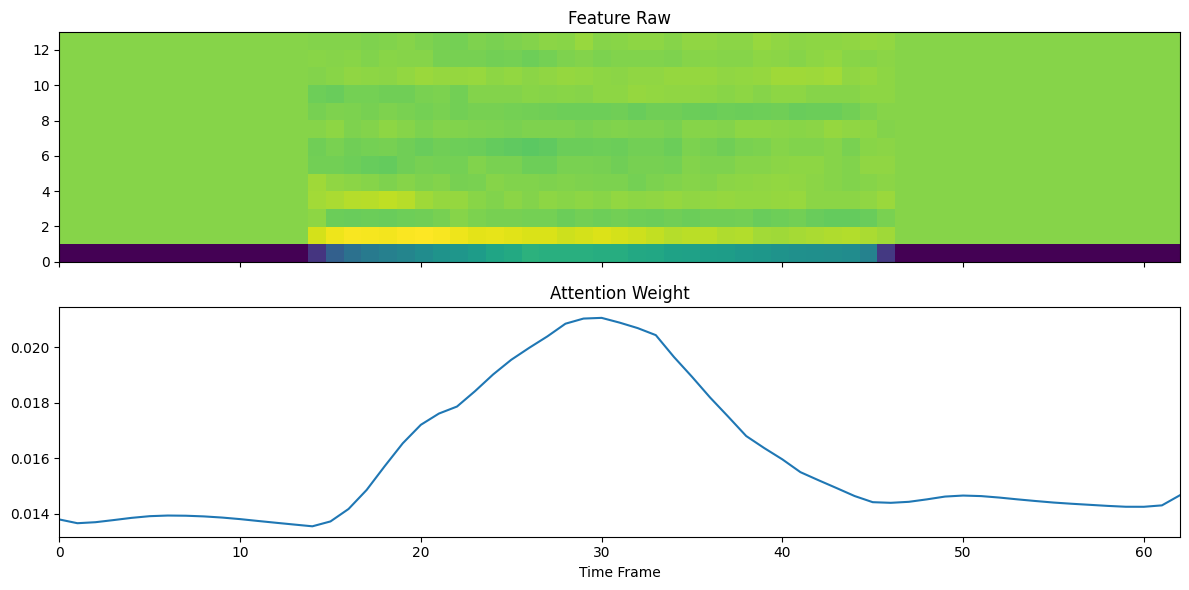

In [31]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True)
time = np.arange(mel_norm.shape[-1])

axes[0].imshow(mel_rgb, aspect='auto', extent=[time[0], time[-1], 0, mel_rgb.shape[0]])
axes[0].set_title("Feature Raw")

axes[1].plot(time, t_att)
axes[1].set_title("Attention Weight")
axes[1].set_xlabel("Time Frame")

plt.tight_layout()
plt.show()

In [6]:
selected_index = random.randint(0, len(audio) - 1)

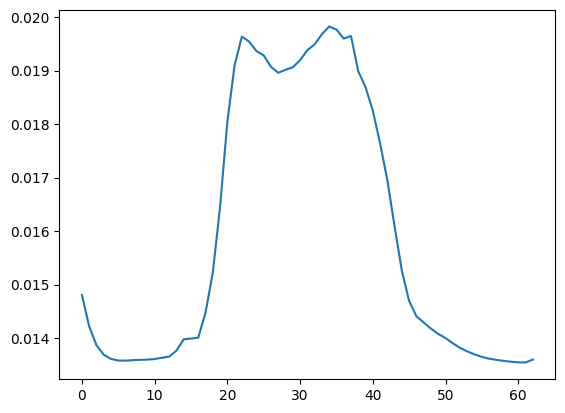

In [33]:
plt.plot(out_model['asp_weights'][selected_index].mean(dim=0).cpu().numpy())

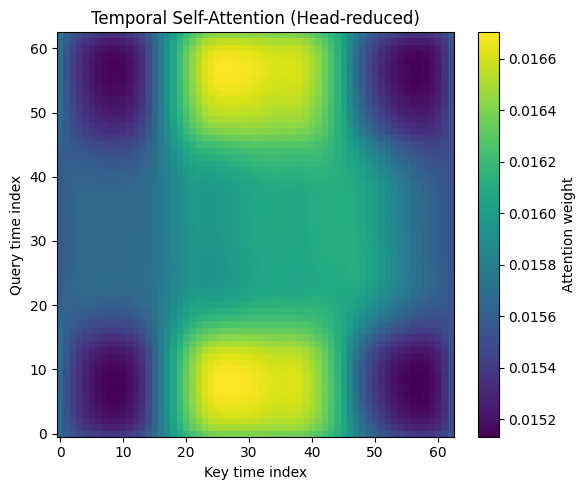

In [36]:
attn = out_model['self_attn_weights'][selected_index].detach().cpu().numpy()
plt.figure(figsize=(6, 5))
plt.imshow(attn, aspect="auto", origin="lower", cmap="viridis")
plt.colorbar(label="Attention weight")
plt.xlabel("Key time index")
plt.ylabel("Query time index")
plt.title("Temporal Self-Attention (Head-reduced)")
plt.tight_layout()
plt.show()

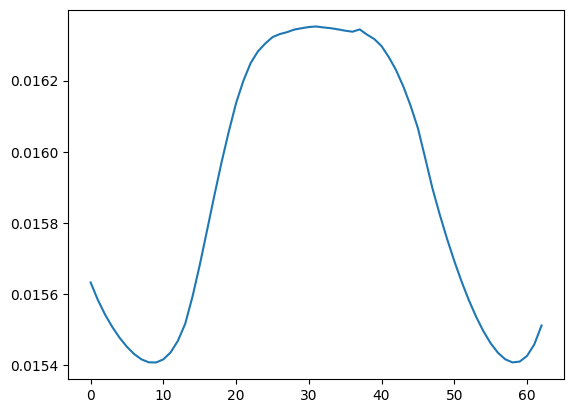

In [37]:
plt.plot(out_model['self_attn_weights'][selected_index].mean(dim=0).detach().cpu().numpy())

In [ ]:
.shape

torch.Size([128, 63, 63])

In [24]:
selected_index

112

In [12]:
out_model.keys()

dict_keys(['disease_logits', 'self_attn_weights', 'asp_weights'])

In [8]:
runner_lightning.probs_threshold = 0.6

In [9]:
df_test_eval = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.test')
df_test_eval = df_test_eval.reset_index(drop=True)
df_test_eval = df_test_eval[hps.data.column_order + ['db']]

results_dict = evaluate_on_dataset(runner_lightning, trainer, df_test_eval, hps, best_fold_idx, collate_fn, db_column='db')
write_results_to_file(results_dict, model_dir, "Test Phase", db_map)

NameError: name 'evaluate_on_dataset' is not defined

In [ ]:
torch.softmax(runner_lightning.model.fusion_logits, dim=0)

AttributeError: 'ResNet34ManualClassifier' object has no attribute 'fusion_logits'

In [ ]:
val_batches = list(val_loader)

In [ ]:
wavnames, audio, _, attention_masks, dse_ids, [patient_ids, _, _] = random.choice(val_batches)
out_model = runner_lightning.model.forward(audio, attention_mask=attention_masks)
logits = out_model['disease_logits']

probs = torch.sigmoid(logits).squeeze(-1) 
preds = (probs >= 0.5).long().cpu().numpy()
labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)

In [ ]:
selected_index = random.randint(0, len(audio) - 1)
mel = audio[selected_index].squeeze(0).cpu()

# split
mel_static = mel[0:80]
mel_delta = mel[80:160]
mel_deltadelta = mel[160:240]

# normalize independently
mel_static_n = minmax_norm(mel_static)
mel_delta_n = minmax_norm(mel_delta)
mel_deltadelta_n = minmax_norm(mel_deltadelta)

# recombine
mel_norm = np.vstack([
    mel_static_n,
    mel_delta_n,
    mel_deltadelta_n
])

mel_np = mel_norm
mel_np = np.flipud(mel_np)

cmap = cm.get_cmap("viridis")
mel_rgb = cmap(mel_np)[..., :3]

print(f"Pred : {preds[selected_index]}")
print(f"True : {labels[selected_index]}")
plt.imshow(mel_rgb)
plt.axis('off')
plt.tight_layout()
plt.show()

RuntimeError: min(): Expected reduction dim to be specified for input.numel() == 0. Specify the reduction dim with the 'dim' argument.

# GradCAM

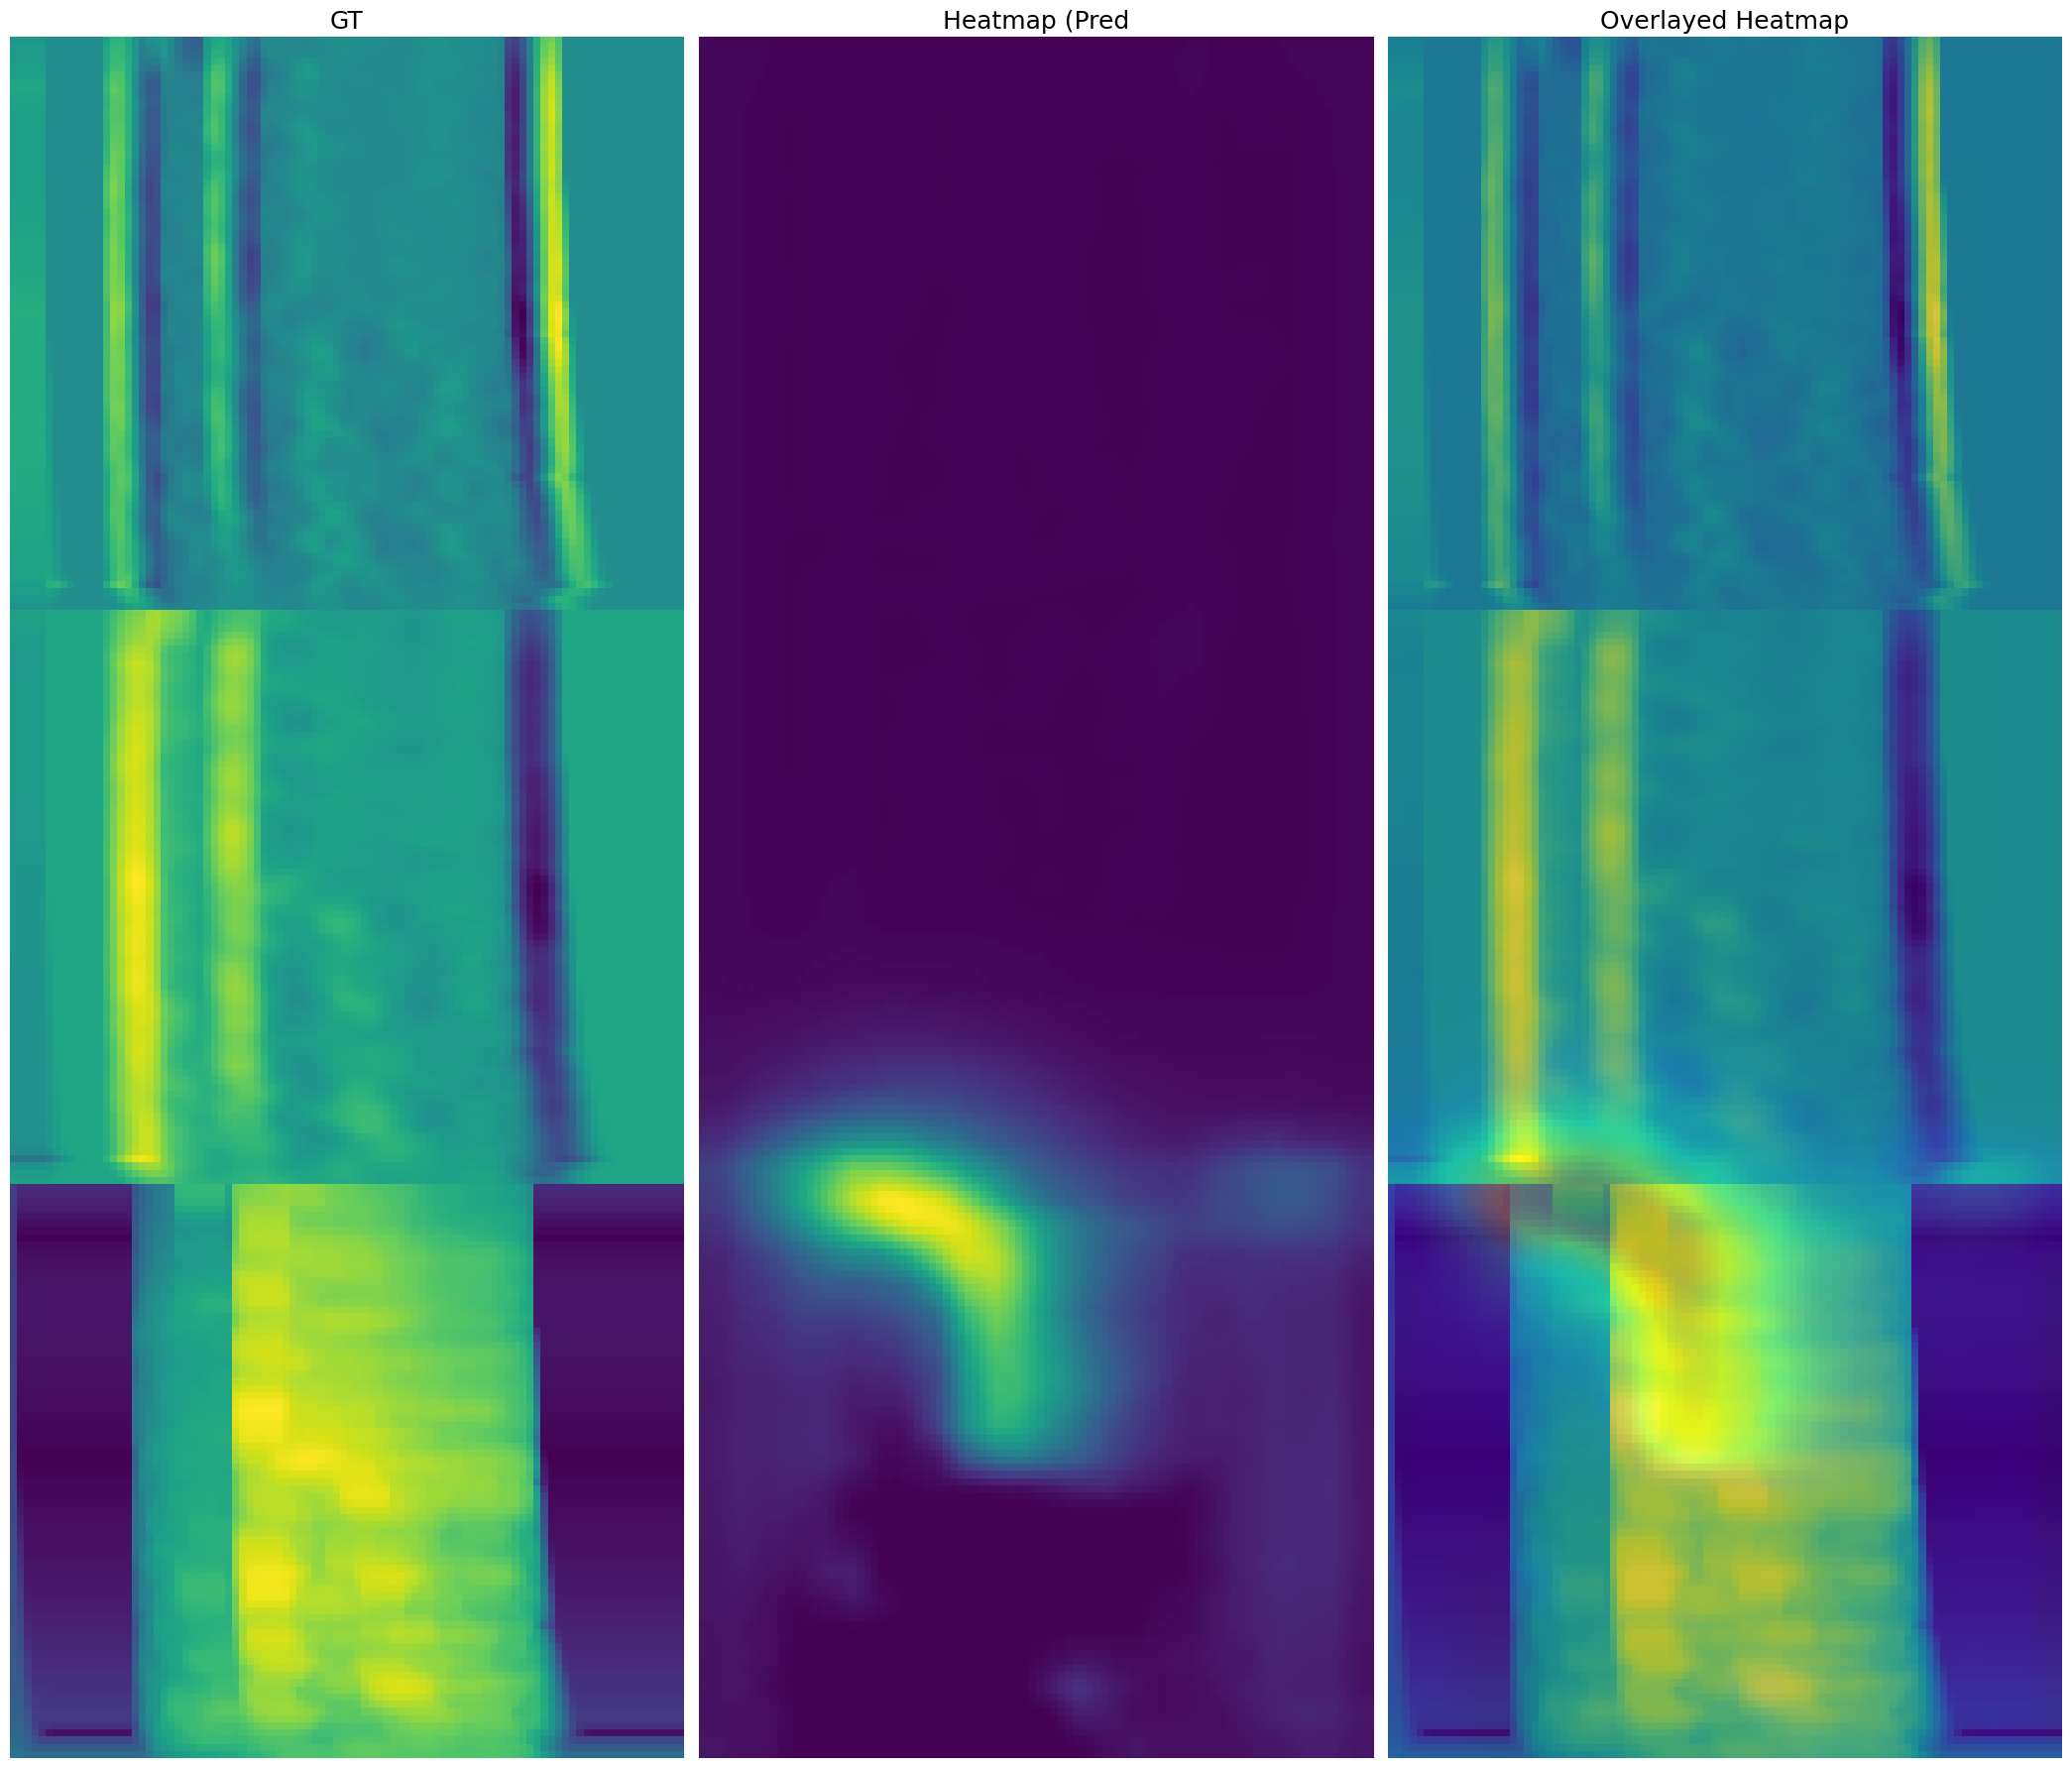

In [16]:
cam_model = CAMWrapper(runner_lightning.model)
target_layers = [runner_lightning.model.layer4, runner_lightning.model.layer3]
targets = [BinaryClassifierOutputTarget(labels[selected_index])]
input_tensor = audio[selected_index]#.squeeze(0)
image_original = mel_rgb

with GradCAM(model=cam_model, target_layers=target_layers) as cam:
  grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
  grayscale_cam = np.flipud(grayscale_cam[0, :])
  visualization = show_cam_on_image(image_original, grayscale_cam, use_rgb=True, image_weight=0.8)
  model_outputs = cam.outputs

images = [image_original, grayscale_cam, visualization]
titles = [f"GT",
            f"Heatmap (Pred",
            "Overlayed Heatmap"]

plt.figure(figsize=(21, 18))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(titles[i], fontdict={"size": 18})
    plt.tight_layout()
plt.show()

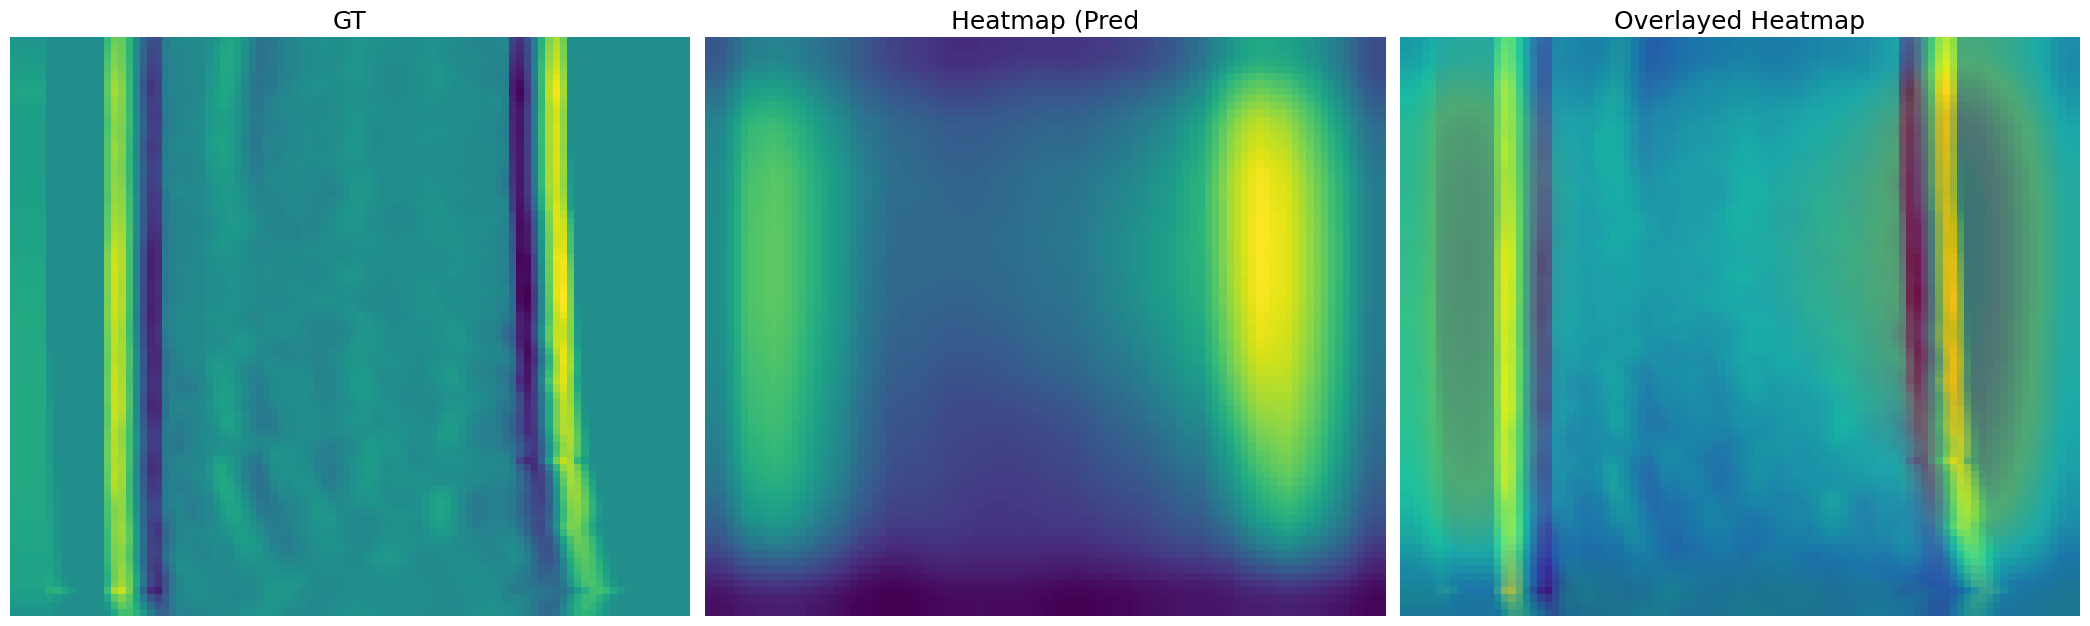

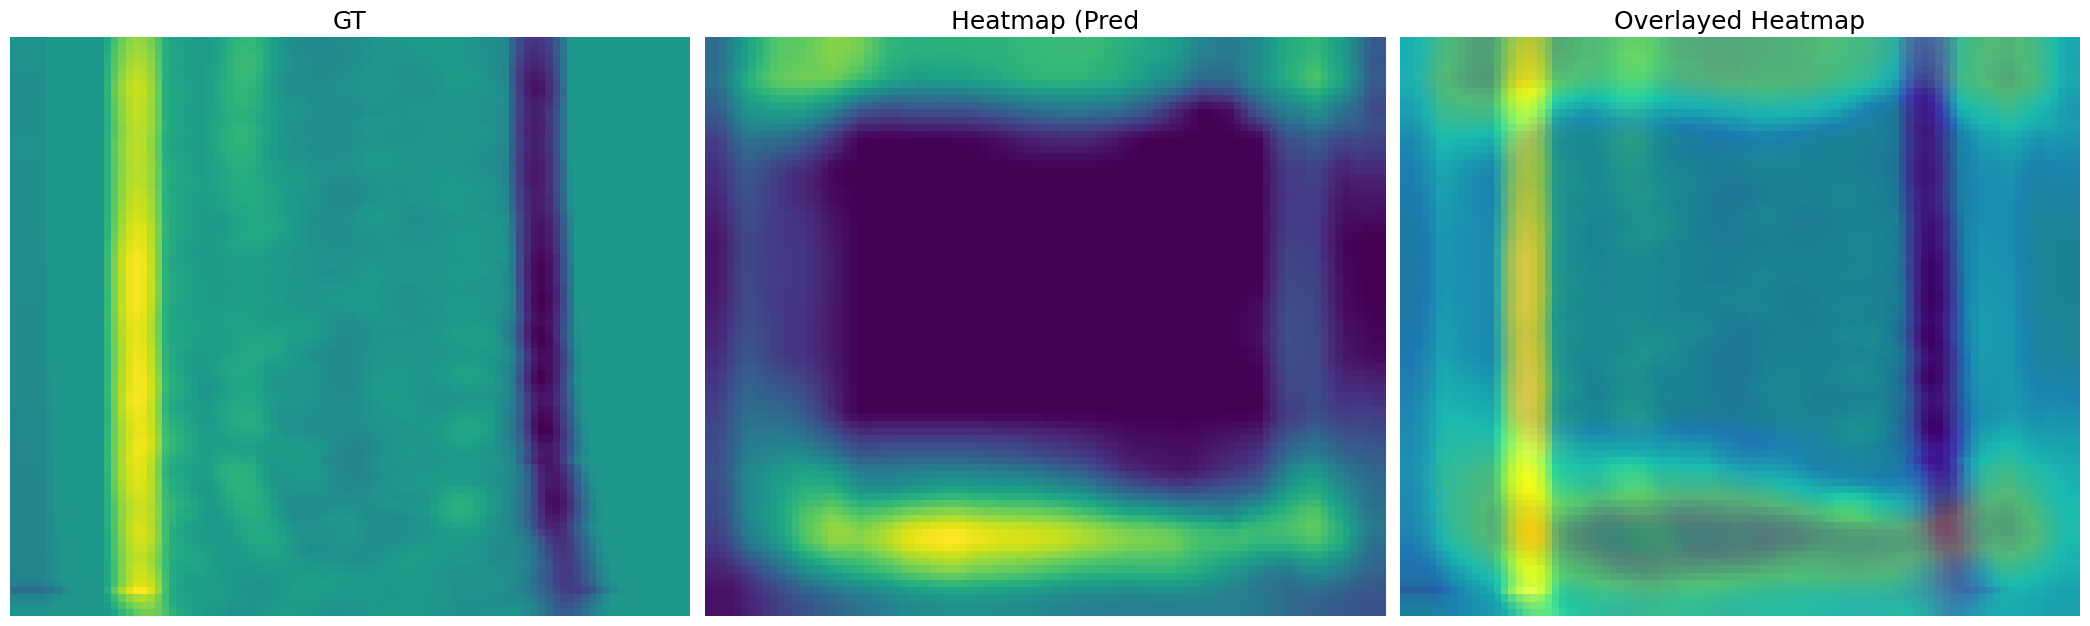

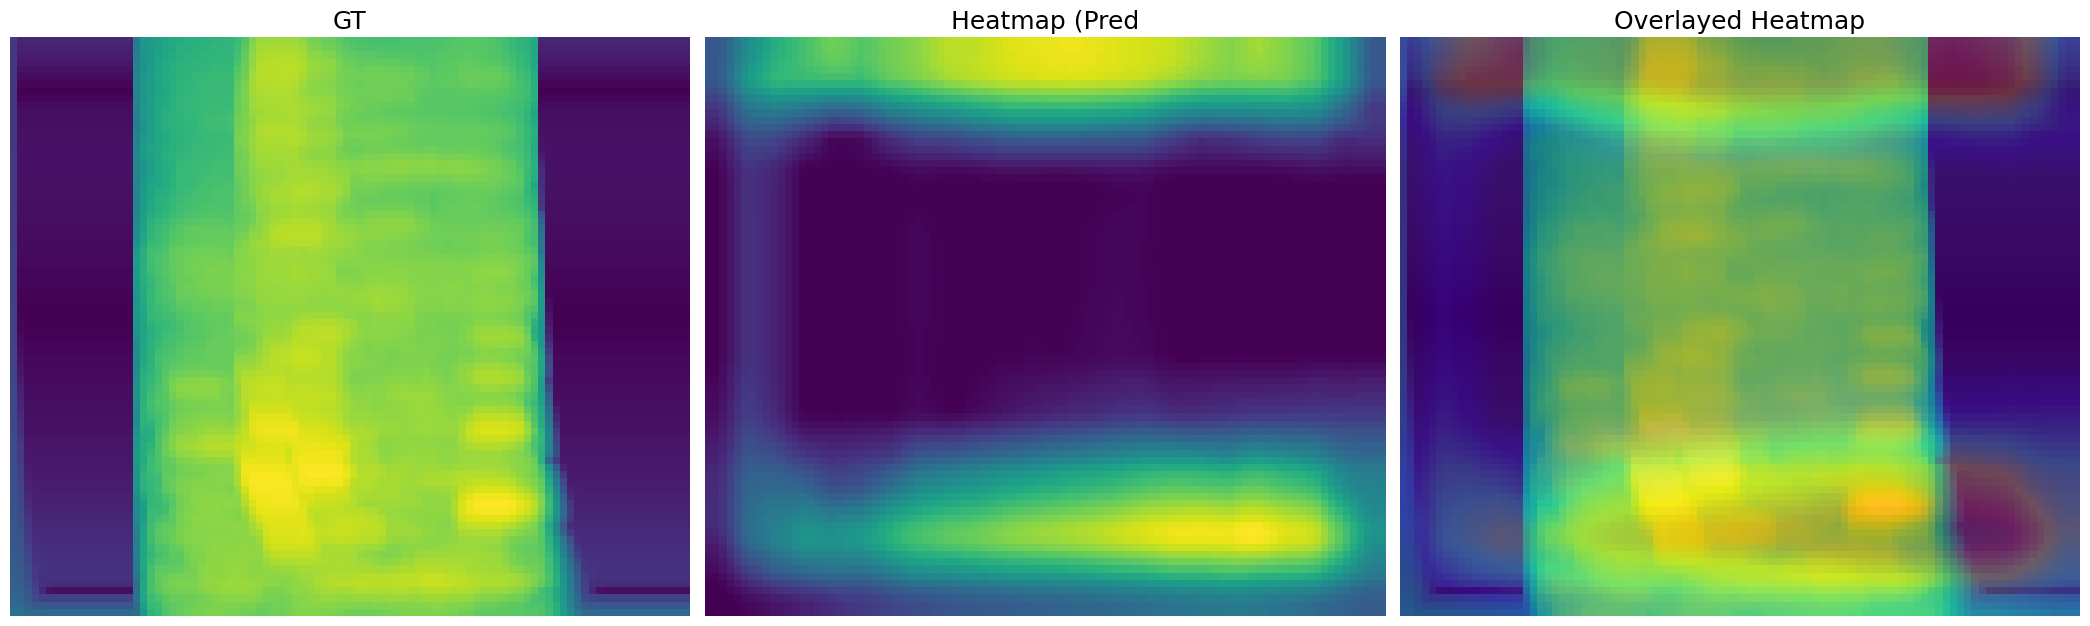

In [16]:
cam_model_split = SplitStreamCAMWrapper(runner_lightning.model, stream_idx=0)
target_layers = [runner_lightning.model.layer4, runner_lightning.model.layer3]

for i, name in enumerate(["raw", "delta", "deltadelta"]):
    streams = torch.split(input_tensor, 80, dim=1)
    s = streams[i]

    splits_original_image = np.split(image_original, 3, axis=0)
    with GradCAM(model=cam_model_split, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=s, targets=targets)
        grayscale_cam = np.flipud(grayscale_cam[0])
        visualization = show_cam_on_image(splits_original_image[i], grayscale_cam, use_rgb=True, image_weight=0.8)

    images = [splits_original_image[i], grayscale_cam, visualization]
    titles = [f"GT",
                f"Heatmap (Pred",
                "Overlayed Heatmap"]

    plt.figure(figsize=(21, 18))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(images[i])
        plt.axis('off')
        plt.title(titles[i], fontdict={"size": 18})
        plt.tight_layout()
    plt.show()


# Attention

In [36]:
selected_index = random.randint(0, len(audio) - 1)
mel = audio[selected_index].squeeze(0).cpu()
t_att = out_model['time_attention'][selected_index].squeeze(-1).cpu().detach().numpy()

# split
mel_static = mel[0:80]
mel_static_n = minmax_norm(mel_static)

# recombine
mel_norm = np.vstack([
    mel_static_n,
])

mel_np = mel_norm
mel_np = np.flipud(mel_np)

cmap = cm.get_cmap("viridis")
mel_rgb = cmap(mel_np)[..., :3]

print(f"Pred : {preds[selected_index]}")
print(f"True : {labels[selected_index]}")

Pred : 1
True : 0


/tmp/ipykernel_88061/3163328918.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


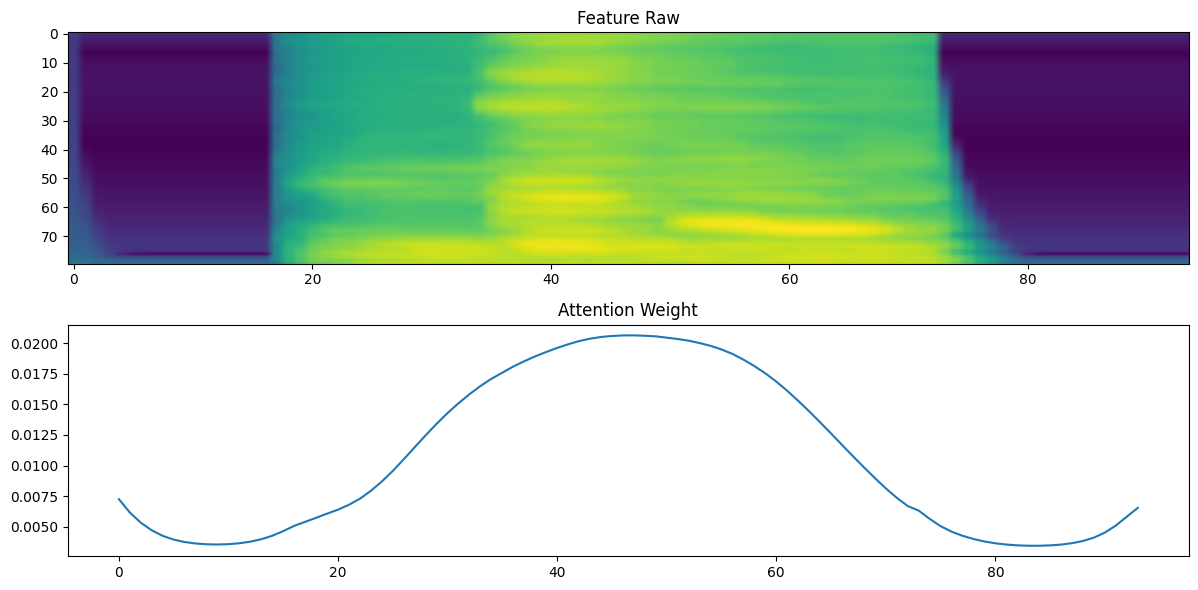

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 6))

axes[0].imshow(mel_rgb, aspect='auto')
axes[0].set_title("Feature Raw")

axes[1].plot(t_att)
axes[1].set_title("Attention Weight")

plt.tight_layout()
plt.show()